# Building a training sample, step by step

This notebook builds **one** `streamgoggles` training sample two ways:

1. **Step by step** — every stage of the pipeline as its own cell, so you can
   see (and plot) what each stage actually produces: study region -> cached
   background (per named matched filter) -> realized stream -> placed in the
   footprint -> injected through the survey model -> cuts/clipping -> window
   -> per-(filter, distance) combined map + stream-only label -> `Sample`.
2. **Minimal command** — the same result via the real pipeline API
   (`StreamInjector.inject_single_stream` / `inject_background_only`), which
   is what `scripts/train.py` (or any dataset loader) actually calls.

All the tunable settings live in **one cell (§1)** as plain dictionaries —
change them and re-run from there to explore a different background source,
richness unit, filter set, pixelization, etc.

**Multiple matched filters, not one** (2026-09-09 pivot, PLAN.md §6.3): each
sample now has one channel per `(filter, distance)` pair, not one per
distance. Alongside a real isochrone filter ("good"), a deliberately "bad"
decoy filter (a plain color-magnitude box, same magnitude range, shifted off
the isochrone locus in color) still lets background contamination through
without preferring real stream stars -- pairing them teaches a network what
contamination looks like versus a real overdensity.

**Detection label, not a literal count** (2026-09-15 pivot, PLAN.md §6.12):
each channel's label starts from that channel's own true stream-only star
count (`stream_raw` — no background mixed in, so it depends on which filter
produced it: the "good" channel's count should be well above the "decoy"
channel's at the stream's true distance), then hard-thresholds it to a
binary {0, 1} "is there a real detection at this pixel" target
(`stream_raw > count_threshold`). This is `label_policy="stream_detection"`
— retargeting the network at the actual goal (a per-pixel detection
probability) instead of the literal count, which turned out to be much
harder to regress accurately than to localize (see the "ML concepts" guide
page and PLAN.md §6.11 for why). The raw, unthresholded count is still
available as `label_policy="stream_count"` for anyone who wants literal
counts; this notebook shows both, since the mechanism is the same up to the
threshold.

Everything here runs against the real `streamobs`/`ugali` machinery (no
mocking), using the `light` synthetic LSST yr1 background by default so it
needs no large data files.

In [1]:
import dataclasses
import tempfile

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

from streamgoggles.background import Background
from streamgoggles.background_sources import (
    DataFileBackgroundSource,
    StreamObsCatalogueBackgroundSource,
    StreamObsLightBackgroundSource,
    StudyRegion,
)
from streamgoggles.data_preparation import Cut, apply_cuts, apply_magnitude_clipping
from streamgoggles.injector import (
    StreamInjector,
    inject_background_only,
    place_stream_in_footprint,
    resolve_richness_to_nstars,
)
from streamgoggles.matched_filter import (
    PixelizationSpec,
    ShiftedColorBoxFilter,
    StreamobsSplineFilter,
    combine_full_maps,
    crop_window,
    finalize_full,
    make_raw_map,
)
from streamgoggles.sample import Sample
from streamgoggles.storage import BackgroundMapStore
from streamgoggles.datasets.transforms import RobustNormalizer, StreamMapTransform
from streamgoggles.stream_sources import StreamObsSource
from streamgoggles.windows import sample_random_window, sample_stream_window
from streamobs.columns import flag_col
from streamobs.observed import StreamInjector as ObsStreamInjector

%matplotlib inline

## 1. Configuration — edit these, then re-run from §2 on

These mirror the shapes of `config/background.yaml`, `config/matched_filter.yaml`
and `config/streams/injection_grid.yaml` (see PLAN.md), just as plain dicts
here so you can tweak a value and immediately see its effect, without
round-tripping through YAML.

`stream_cfg["richness"]` takes exactly one of `nstars` / `mass` (Msun) /
`surface_brightness` (mag/arcsec^2) — whichever you set is converted to a
true star count by `resolve_richness_to_nstars` in §2.4 (decision 16/§4.1).

`cuts_cfg`/`clipping_cfg` are their **own** top-level dicts, not nested
inside `background_cfg` — they're shared, catalog-agnostic settings
(`data_preparation.apply_cuts`/`apply_magnitude_clipping`, decision 13),
applied identically to the background catalog (§2.3) *and* the injected
stream catalog (§2.6). Nesting them under `background_cfg` would suggest
they're background-specific, which is exactly backwards.

`filters_cfg` is an **ordered** dict: a `"shifted_box"` entry is built by
shifting off its own `reference` filter's polygon, so `reference` must
already be a key earlier in the dict. `"good"` should normally come first.

`matched_filter_cfg["pixelization"]["nside"]` is fixed at **512** (the
standard resolution for stream search, PLAN.md §6.12) — `pixel_scale_deg`
is intentionally absent from the dict below so it's always auto-derived
from `nside` alone, never picked by hand. `count_threshold` sets the
`label_policy="stream_detection"` cut (§2.8/§3): a pixel counts as a
detection once its true stream-only star count exceeds this value.

**Found while building this notebook (2026-09-09):** `config/background.yaml`'s
own default cuts (`quantity: snr`) don't actually work with its own default
`source: light` — the `light` generator doesn't produce per-star error
columns at all (only `injection`/`data_file` do), so an "snr" cut has no
column to read (`KeyError`). Fixed in `background.yaml` itself; the cuts
below use `"mag"`, which every source produces.

In [2]:
SEED = 42

study_region_cfg = dict(center_ra=0.0, center_dec=-30.0, width_deg=25.0, height_deg=18.0)

# Shared, catalog-agnostic (decision 13) -- applied identically to the
# background (§2.3) and the injected stream (§2.6), not background-specific.
cuts_cfg = [
    # "snr" cuts need per-star error columns, which only "injection"/
    # "data_file" background sources produce -- not "light" (see note above);
    # the injected stream always has them, since streamobs's own injector
    # always reports one.
    dict(quantity="mag", band="g", op="<", value=26.5),
    dict(quantity="mag", band="r", op="<", value=26.0),
]
clipping_cfg = {"g": {"min": 16.0, "max": 26.5}, "r": {"min": 16.0, "max": 26.0}}

background_cfg = dict(
    source="light",       # "data_file" | "light" | "injection"
    survey="lsst",
    release="yr1",         # "yr1" (synthetic forecast) or "dp2" (real skim, data_file only)
    source_kwargs={},      # extra kwargs for the chosen BackgroundSource.load()
    finalize={"enabled": False},  # background-subtraction not implemented yet (matched_filter.finalize_full)
)

# Named matched filters (2026-09-09 pivot, PLAN.md §6.3) -- one channel per
# (filter, distance) pair. "decoy" is a plain color-magnitude box, same
# magnitude range as "good" at each distance, shifted off the isochrone
# locus in color -- still lets background contamination through, without
# preferring real stream stars.
filters_cfg = dict(
    good=dict(type="isochrone", reference_isochrone=dict(age=12.5, z=0.0002)),
    decoy=dict(type="shifted_box", reference="good", color_shift=0.5, color_width=0.3),
)

# nside=512 (PLAN.md §6.12): the standard HEALPix resolution for stream
# search. pixel_scale_deg is deliberately NOT set here -- PixelizationSpec
# auto-derives it from nside alone (native_pixel_scale_deg), so the pixel
# size is never picked by hand; only image_size_pix (the window's extent in
# PIXELS, independent of nside) is a free choice, kept here at a size that
# comfortably covers the stream's length below with margin for a random
# window placement/rotation (window <= 30 deg cap, decision 21).
matched_filter_cfg = dict(
    bands=["g", "r"],
    pixelization=dict(nside=512, image_size_pix=(96, 96)),
    distance_moduli=[16.0, 16.8],  # trial distances scanned; 16.8 matches the stream below
)

# count_threshold: used below (§2.8/§3) to build the label_policy=
# "stream_detection" binary target from the raw stream-only count
# (PLAN.md §6.12) -- a pixel is "detected" once its true stream-only count
# exceeds this many stars. Same value StreamInjector's own
# label_policy="stream_detection" uses when you pass count_threshold to it.
count_threshold = 10.0

stream_cfg = dict(
    morphology="uniform",       # "uniform" | "spline" (decision 5)
    # surface_brightness=30 (not nstars=3000, the pre-nside=512 default):
    # at nside=512's much finer native pixel scale (~0.11 deg/pixel vs the
    # old demo's 1 deg/pixel), the same total star count spreads over far
    # more, smaller pixels, so per-pixel counts drop a lot -- verified for
    # real (PLAN.md §6.12) that a modest richness like nstars=3000 (or even
    # surface_brightness=32-33) no longer clears count_threshold=10
    # ANYWHERE in the window at this resolution. surface_brightness=30 (the
    # bright end of the already-established 30-33 working range) reliably
    # does, so the walkthrough below actually has something to show.
    richness={"surface_brightness": 30.0},  # or {"nstars": ...} or {"mass": ...}
    width=0.2,
    length=8.0,
    distance_modulus=16.8,
    age=12.5,
    z=0.0002,
)

window_cfg = dict(min_stream_length_deg=5.0, max_attempts=100)  # decision 21

namespace = f"{background_cfg['survey']}_{background_cfg['release']}"
rng = np.random.default_rng(SEED)

## 2. Step by step

### 2.1 Study region — where synthetic background may be generated at all

A plain RA/Dec box (decision 24), independent of and larger than any one
sample's window.

In [3]:
study_region = StudyRegion(**study_region_cfg)
study_region

StudyRegion(center_ra=0.0, center_dec=-30.0, width_deg=25.0, height_deg=18.0)

### 2.2 Pixelization and matched filters

`PixelizationSpec` fixes the HEALPix `nside` — 512 here, the standard
resolution for stream search (PLAN.md §6.12) — and auto-derives
`pixel_scale_deg` from it alone (never set by hand; see
`matched_filter_demo.ipynb` for that mechanism in detail). `image_size_pix`
is a separate, independent choice: it's the window's extent in pixels, not
tied to nside at all, picked here just large enough to comfortably contain
the stream below. Each matched filter is a hard color-magnitude cut:
`"good"` around a reference isochrone (age, metallicity), `"decoy"` a plain
box shifted off it in color, sharing `"good"`'s magnitude range at each
trial distance.

In [4]:
pix = PixelizationSpec(**matched_filter_cfg["pixelization"])

matched_filters = {}
for name, cfg in filters_cfg.items():
    if cfg["type"] == "isochrone":
        matched_filters[name] = StreamobsSplineFilter(
            iso_config=cfg["reference_isochrone"], namespace=namespace
        )
    elif cfg["type"] == "shifted_box":
        matched_filters[name] = ShiftedColorBoxFilter(
            reference_filter=matched_filters[cfg["reference"]],
            color_shift=cfg["color_shift"],
            color_width=cfg["color_width"],
        )
    else:
        raise ValueError(f"unknown filter type {cfg['type']!r}")

matched_filters

{'good': <streamgoggles.matched_filter.StreamobsSplineFilter at 0x125c1b770>,
 'decoy': <streamgoggles.matched_filter.ShiftedColorBoxFilter at 0x1055960c0>}

### 2.3 Background: load, cut, clip, cache the raw maps (per filter)

`Background.load_or_cache` does four things in one call: pick the
`BackgroundSource` for `background_cfg["source"]`, load its catalog
(restricted to `study_region` for the synthetic sources), apply the *same*
cuts/clipping the stream will get in §2.6, and — for every `(filter,
distance)` pair — run that filter **once** and cache the resulting raw
HEALPix count map (`BackgroundMapStore`, here a throwaway temp directory so
this demo never touches `data/background_maps/`).

This is the *only* place any matched filter ever touches the background —
every stream injected below (however many) reuses these cached maps rather
than re-running `select()` on the background catalog.

In [5]:
source_classes = {
    "data_file": DataFileBackgroundSource,
    "light": StreamObsLightBackgroundSource,
    "injection": StreamObsCatalogueBackgroundSource,
}
background_source = source_classes[background_cfg["source"]]()
cuts = [Cut(**c) for c in cuts_cfg]

store = BackgroundMapStore(tempfile.mkdtemp(prefix="streamgoggles_demo_bgmaps_"))

background = Background.load_or_cache(
    source=background_source,
    source_cfg=background_cfg["source_kwargs"],
    study_region=study_region,
    cuts=cuts,
    clipping=clipping_cfg,
    matched_filters=matched_filters,
    bands=matched_filter_cfg["bands"],
    distance_moduli=matched_filter_cfg["distance_moduli"],
    finalize_cfg=background_cfg["finalize"],
    store=store,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    filter_configs=filters_cfg,
)
print(f"background catalog: {len(background.catalog)} stars (after cuts+clipping)")
print(f"footprint: {background.footprint.sum()} / {len(background.footprint)} HEALPix pixels valid")
print(f"cached filters: {list(background.raw_map_full_dict)}")

Loading survey data for 'lsst_yr1'...
  Loading config from: lsst_yr1.yaml

LOADING SURVEY DATA FILES
Survey data directory: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/surveys/lsst_yr1

Fallback directory for shared data files: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/others

Available bands: g, i, r, u, y, z


Loading survey properties...
Loading magnitude limit maps...
  ✓ Success for g-band magnitude limit
  ⚠ Warning: 'maglim_map_i' not specified in config (skipping i-band)
  ✓ Success for r-band magnitude limit
  ⚠ Warning: 'maglim_map_u' not specified in config (skipping u-band)
  ⚠ Warning: 'maglim_map_y' not specified in config (skipping y-band)
  ⚠ Warning: 'maglim_map_z' not specified in config (skipping z-band)

Loading completeness/efficiency function...
  Loading Completeness/efficiency function...
    File: lsst_dc2_stellar_efficiency_cutr.csv
    ✓ Success
  Loading Detection efficiency function...
    File: lsst_dc

/Users/pelissier/Documents/Codes/packages/streamobs/streamobs/background/background.py:159: UserWarning: Requested nside=4096 exceeds the magnitude-limit map resolution (nside=128). Capping to nside=128.
  return gen.generate(


background catalog: 6399584 stars (after cuts+clipping)
footprint: 34318 / 3145728 HEALPix pixels valid
cached filters: ['good', 'decoy']


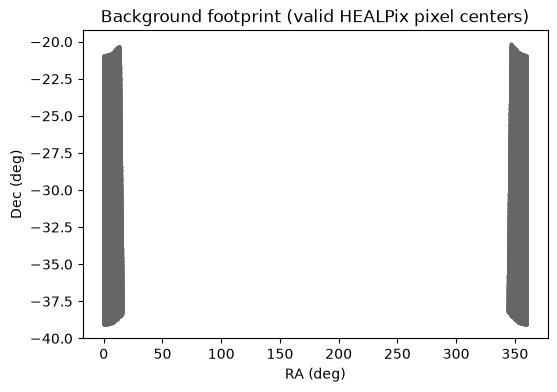

In [6]:
fp_ra, fp_dec = hp.pix2ang(pix.nside, np.flatnonzero(background.footprint), lonlat=True)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(fp_ra, fp_dec, s=4, color="0.4")
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("Background footprint (valid HEALPix pixel centers)")
plt.show()

### 2.4 Realize the stream — richness resolved to a true star count

`resolve_richness_to_nstars` converts whichever unit `stream_cfg["richness"]`
is expressed in (nstars / mass / surface_brightness) to an integer `nstars`,
using `inject_utils`'s conversions. The stream is then realized in its own
`phi1`/`phi2` frame with TRUE (noiseless) magnitudes — nothing about the sky
or survey yet.

In [7]:
richness_kind, richness_value = next(iter(stream_cfg["richness"].items()))
stream_params = {k: v for k, v in stream_cfg.items() if k != "richness"}
stream_params["richness"] = richness_value
stream_params = resolve_richness_to_nstars(stream_params, richness_kind)
print(f"richness_kind={richness_kind!r}, value={richness_value} -> nstars={stream_params['nstars']}")

stream_df = StreamObsSource().realize(stream_params, rng)
stream_df.head()

richness_kind='surface_brightness', value=30.0 -> nstars=178331


,phi1,phi2,dist,is_stream,lsst_g_true,lsst_r_true
0,2.191648,0.038032,16.8,True,25.105640,24.401095
1,-0.488972,-0.044475,16.8,True,27.768083,26.725205
2,2.868783,-0.001792,16.8,True,26.646945,25.730404
3,1.578944,0.010164,16.8,True,26.272335,25.401006
4,-3.246581,0.176728,16.8,True,28.487723,27.357877


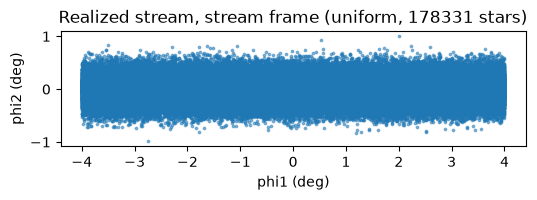

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(stream_df["phi1"], stream_df["phi2"], s=3, alpha=0.5)
ax.set_xlabel("phi1 (deg)")
ax.set_ylabel("phi2 (deg)")
ax.set_title(f"Realized stream, stream frame ({stream_params['morphology']}, {len(stream_df)} stars)")
ax.set_aspect("equal")
plt.show()

### 2.5 Place the stream in the footprint

Picks a random valid footprint pixel + random position angle and builds a
great-circle frame there (decision: not streamobs's own `_find_gc_frame`
rejection search, which fails against a footprint this narrow — see
`injector.py`'s `place_stream_in_footprint` docstring), giving every star a
real `ra`/`dec`.

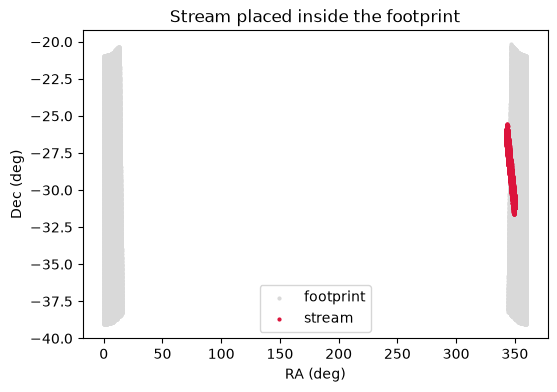

In [9]:
placed_df = place_stream_in_footprint(stream_df, background.footprint, pix.nside, rng)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(fp_ra, fp_dec, s=4, color="0.85", label="footprint")
ax.scatter(placed_df["ra"], placed_df["dec"], s=4, color="crimson", label="stream")
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.legend()
ax.set_title("Stream placed inside the footprint")
plt.show()

### 2.6 Inject through the survey model, then apply the same cuts/clipping as the background

`streamobs.observed.StreamInjector.inject()` adds observed (noisy)
magnitudes, reported errors, and a detection flag — using the *same*
`ra`/`dec` already set in §2.5, since it only fills in columns that are
missing. Undetected stars carry a `"BAD_MAG"` sentinel instead of a number,
so they're filtered out (via the detection flag) before anything downstream
touches those columns numerically. What's left then gets the *identical*
`apply_cuts`/`apply_magnitude_clipping` calls the background got in §2.3
(decision 13) — same function, same config, so selection is consistent
regardless of whether a star is real background or injected stream.

In [10]:
obs_injector = ObsStreamInjector(background_cfg["survey"], release=background_cfg["release"])
injected_df = obs_injector.inject(
    placed_df, bands=matched_filter_cfg["bands"], rng=rng, verbose=False
)
detected = injected_df[injected_df[flag_col(namespace)]].reset_index(drop=True)
print(f"{len(detected)} / {len(injected_df)} stream stars detected by the survey model")

detected = apply_cuts(detected, cuts, namespace=namespace, verbose=False)
if clipping_cfg:
    detected = apply_magnitude_clipping(detected, clipping_cfg, namespace=namespace)
print(f"{len(detected)} stream stars remain after cuts + magnitude clipping")
detected.head()

✓ Using cached survey data for 'lsst_yr1'


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


19346 / 178331 stream stars detected by the survey model
19328 stream stars remain after cuts + magnitude clipping


,phi1,phi2,dist,is_stream,lsst_g_true,lsst_r_true,ra,dec,lsst_yr1_g_obs,lsst_yr1_g_err,lsst_yr1_r_obs,lsst_yr1_r_err,lsst_yr1_flag_observed
0,-0.452686,0.016076,16.8,True,23.935931,23.402746,345.819523,-28.326612,23.975033,0.045002,23.359546,0.029309,True
1,2.064702,-0.144900,16.8,True,25.563788,24.789541,347.918162,-30.060764,25.871652,0.178947,24.701614,0.097645,True
2,2.227068,0.009699,16.8,True,24.705411,24.060098,348.176410,-30.043539,24.725372,0.111480,24.0259,0.058789,True
3,-2.765684,-0.263028,16.8,True,25.076000,24.375979,343.635976,-27.027004,25.401922,0.198677,24.422545,0.091646,True
4,-1.393397,0.310075,16.8,True,20.035020,19.666820,345.224734,-27.492879,20.033975,0.005343,19.660166,0.005197,True


### 2.7 Sample a window

Rejection-samples a window (same pixel size as `pix`) with >= 5 deg of
stream track inside it (decision 21) — a floor, not a guarantee of full
inclusion.

In [11]:
size_deg = pix.image_size_pix[0] * pix.pixel_scale_deg
window = sample_stream_window(
    detected["ra"].to_numpy(dtype=float),
    detected["dec"].to_numpy(dtype=float),
    stream_params.get("width", 0.0),
    background.footprint,
    pix.nside,
    size_deg=size_deg,
    min_stream_length_deg=window_cfg["min_stream_length_deg"],
    max_attempts=window_cfg["max_attempts"],
    rng=rng,
)
window

Window(center_ra=346.35734612338797, center_dec=-28.02888308290495, rotation_deg=178.08562089096725, width_deg=np.float64(10.9935565178157), height_deg=np.float64(10.9935565178157))

### 2.8 Per (filter, distance) channel: select, combine, finalize, crop -- and the label

For each trial distance, for each named filter: that filter selects which
stream stars are color-magnitude-consistent with *that* channel, those get
their own raw HEALPix count map (`stream_raw` — the true stream-only count,
no background mixed in). It's added to that filter's own cached background
map (§2.3), optionally finalized (identity here — background subtraction
isn't implemented yet, decision 18 default off), and cropped/projected to
the window. Channels are ordered distance-major, filter-minor -- the same
order `Sample.metadata["channels"]` records.

`stream_raw`'s window crop is also exactly `label_policy="stream_count"`'s
label. This notebook's default is `label_policy="stream_detection"`
(PLAN.md §6.12) instead: hard-threshold that same crop at `count_threshold`
stars to get a binary detection target. Both are shown below — the raw
count (still useful to look at directly) and the thresholded label actually
used as `Sample.label_stack`.

In [12]:
channels_meta = []
bg_channels, raw_count_channels, label_channels, combined_channels = [], [], [], []
valid_mask = None

for dm in matched_filter_cfg["distance_moduli"]:
    for filter_name, mf in matched_filters.items():
        selected = mf.select(detected, matched_filter_cfg["bands"], dm)
        stream_raw, _ = make_raw_map(detected, selected, pix)
        bg_raw = background.raw_map_full_dict[filter_name][dm]
        combined_raw = combine_full_maps(bg_raw, stream_raw, background.valid_mask_full)
        finalized = finalize_full(combined_raw, background.valid_mask_full, background_cfg["finalize"])

        windowed_bg, _ = crop_window(bg_raw, background.valid_mask_full, window, pix)
        windowed_raw_count, _ = crop_window(stream_raw, background.valid_mask_full, window, pix)
        windowed_combined, windowed_valid = crop_window(finalized, background.valid_mask_full, window, pix)
        # label_policy="stream_detection" (PLAN.md §6.12): hard-threshold the
        # same raw count crop instead of returning it directly -- exactly
        # what injector.py's inject_single_stream does internally.
        windowed_label = (windowed_raw_count > count_threshold).astype(np.float32)

        bg_channels.append(windowed_bg)
        raw_count_channels.append(windowed_raw_count)
        label_channels.append(windowed_label)
        combined_channels.append(windowed_combined)
        if valid_mask is None:
            valid_mask = windowed_valid
        channels_meta.append({"filter": filter_name, "distance_modulus": dm})

map_stack = np.stack(combined_channels, axis=0).astype(np.float32)
label_stack = np.stack(label_channels, axis=0).astype(np.float32)
print(f"map_stack shape: {map_stack.shape} (n_dist * n_filters, ny, nx)")
print(f"raw stream-only count, peak per channel: {[c.max() for c in raw_count_channels]}")
print(f"detection label (count > {count_threshold}), positive pixels per channel: {label_stack.sum(axis=(1, 2))}")

map_stack shape: (4, 96, 96) (n_dist * n_filters, ny, nx)
raw stream-only count, peak per channel: [np.float64(26.945359589929513), np.float64(10.47476534277649), np.float64(61.99695623274504), np.float64(12.183737450387389)]
detection label (count > 10.0), positive pixels per channel: [158.   1. 258.   7.]


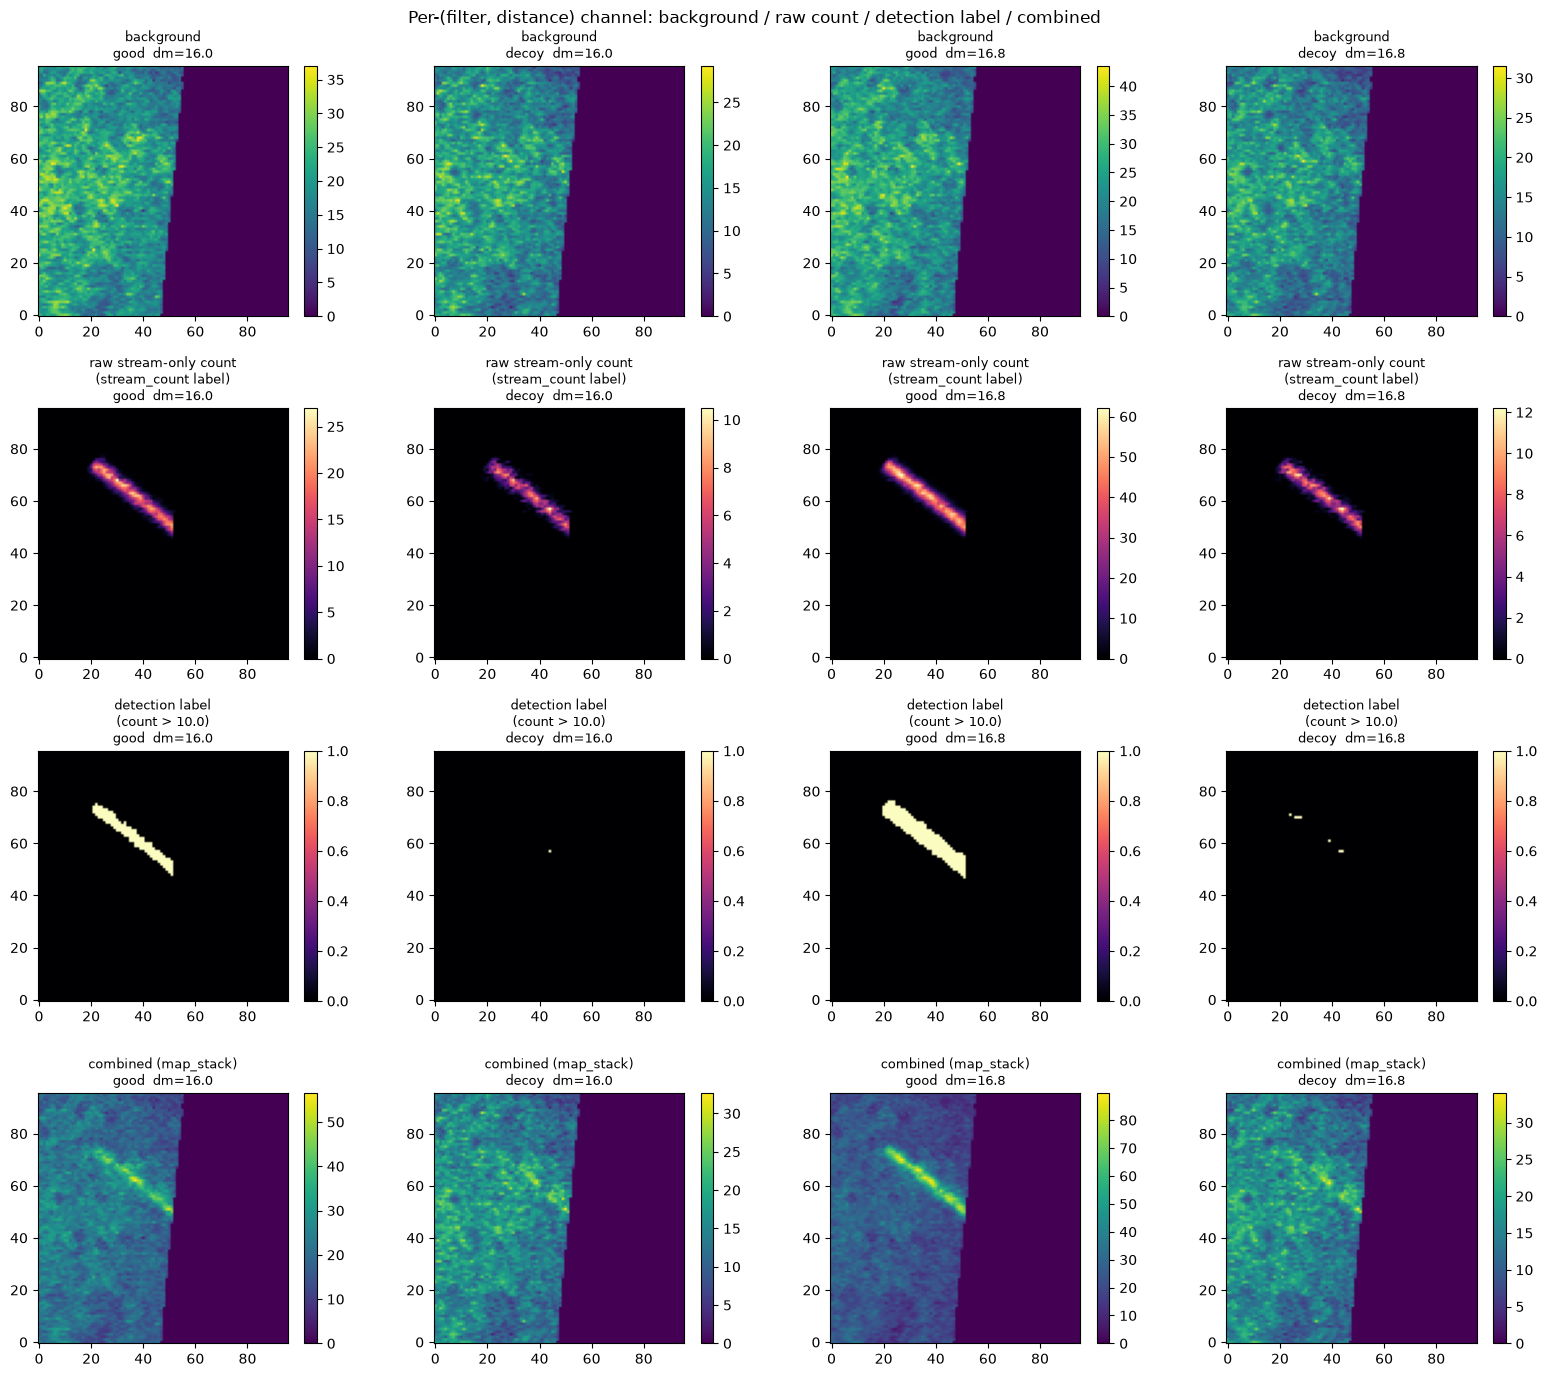

In [13]:
n_cols = len(channels_meta)
fig, axes = plt.subplots(4, n_cols, figsize=(4 * n_cols, 14), squeeze=False)
row_specs = [
    (bg_channels, "background", "viridis", {}),
    (raw_count_channels, "raw stream-only count\n(stream_count label)", "magma", {}),
    (label_channels, f"detection label\n(count > {count_threshold})", "magma", dict(vmin=0, vmax=1)),
    (combined_channels, "combined (map_stack)", "viridis", {}),
]
for j, meta in enumerate(channels_meta):
    for i, (channels, row_label, cmap, kwargs) in enumerate(row_specs):
        ax = axes[i, j]
        im = ax.imshow(channels[j], origin="lower", cmap=cmap, **kwargs)
        ax.set_title(f"{row_label}\n{meta['filter']}  dm={meta['distance_modulus']}", fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Per-(filter, distance) channel: background / raw count / detection label / combined")
plt.tight_layout()
plt.show()

### 2.9 Assemble the `Sample`

Bundles everything `storage.SimulationStore` would persist. `channels`
records the exact `(filter, distance)` meaning of every `map_stack`/
`label_stack` index.

In [14]:
sample_manual = Sample(
    map_stack=map_stack,
    label_stack=label_stack,
    valid_mask=valid_mask,
    params=stream_params,
    metadata={
        "window": dataclasses.asdict(window),
        "distance_moduli": matched_filter_cfg["distance_moduli"],
        "channels": channels_meta,
    },
)
sample_manual

Sample(map_stack=array([[[26.441   , 23.232796, 17.25385 , ...,  0.      ,  0.      ,
          0.      ],
        [22.958714, 17.50281 , 20.386398, ...,  0.      ,  0.      ,
          0.      ],
        [21.090006, 18.997965, 17.665508, ...,  0.      ,  0.      ,
          0.      ],
        ...,
        [19.122988, 19.37141 , 13.414931, ...,  0.      ,  0.      ,
          0.      ],
        [21.360003, 22.590433, 15.6183  , ...,  0.      ,  0.      ,
          0.      ],
        [18.461445, 22.449434, 21.71441 , ...,  0.      ,  0.      ,
          0.      ]],

       [[18.70246 , 18.762476, 16.305191, ...,  0.      ,  0.      ,
          0.      ],
        [16.645702, 13.766517, 14.129769, ...,  0.      ,  0.      ,
          0.      ],
        [16.700722, 16.226036, 15.351821, ...,  0.      ,  0.      ,
          0.      ],
        ...,
        [13.958018, 12.678198, 13.027936, ...,  0.      ,  0.      ,
          0.      ],
        [15.735176, 14.9967  , 12.394667, ...,  0.     

## 3. The same thing, minimal command

Everything in §2.4-2.9 is exactly what `StreamInjector.inject_single_stream`
does internally, given the same `background`/`matched_filters` built in
§2.2-2.3 (reused here, not rebuilt — matched filters must still only ever
touch the background once). One call, one `Sample`. `label_policy` defaults
to `"stream_count"` on `StreamInjector` itself; passed explicitly here as
`"stream_detection"` (with `count_threshold`) to match §2.8's walkthrough
and this project's current default direction (PLAN.md §6.12).

In [15]:
injector = StreamInjector(
    background=background,
    matched_filters=matched_filters,
    stream_source=StreamObsSource(),
    cuts=cuts,
    clipping=clipping_cfg,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    bands=tuple(matched_filter_cfg["bands"]),
    richness_kind=richness_kind,
    finalize_cfg=background_cfg["finalize"],
    label_policy="stream_detection",
    count_threshold=count_threshold,
)

stream_params_raw = {k: v for k, v in stream_cfg.items() if k != "richness"}
stream_params_raw["richness"] = richness_value

sample_minimal = injector.inject_single_stream(stream_params_raw, np.random.default_rng(SEED))
sample_minimal

✓ Using cached survey data for 'lsst_yr1'


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Sample(map_stack=array([[[26.441   , 23.232796, 17.25385 , ...,  0.      ,  0.      ,
          0.      ],
        [22.958714, 17.50281 , 20.386398, ...,  0.      ,  0.      ,
          0.      ],
        [21.090006, 18.997965, 17.665508, ...,  0.      ,  0.      ,
          0.      ],
        ...,
        [19.122988, 19.37141 , 13.414931, ...,  0.      ,  0.      ,
          0.      ],
        [21.360003, 22.590433, 15.6183  , ...,  0.      ,  0.      ,
          0.      ],
        [18.461445, 22.449434, 21.71441 , ...,  0.      ,  0.      ,
          0.      ]],

       [[18.70246 , 18.762476, 16.305191, ...,  0.      ,  0.      ,
          0.      ],
        [16.645702, 13.766517, 14.129769, ...,  0.      ,  0.      ,
          0.      ],
        [16.700722, 16.226036, 15.351821, ...,  0.      ,  0.      ,
          0.      ],
        ...,
        [13.958018, 12.678198, 13.027936, ...,  0.      ,  0.      ,
          0.      ],
        [15.735176, 14.9967  , 12.394667, ...,  0.     

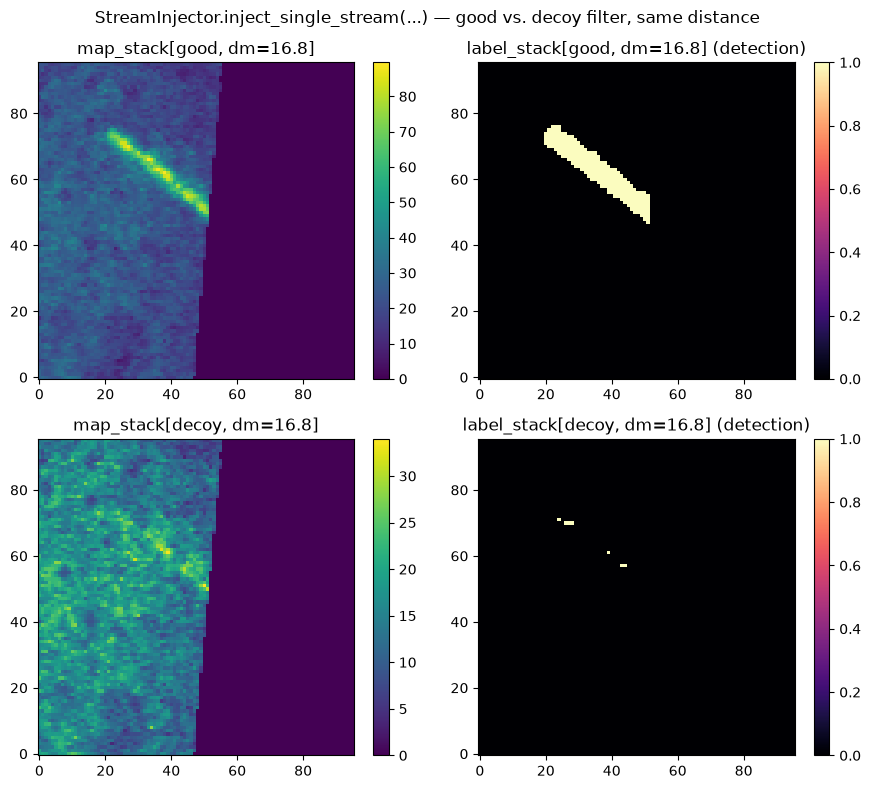

detected pixels, good:  258
detected pixels, decoy: 7


In [16]:
# Pick whichever trial distance is closest to the stream's own true
# distance_modulus, from matched_filter_cfg -- not a hardcoded value, so
# this stays correct if either config dict above changes.
channels_minimal = sample_minimal.metadata["channels"]
closest_dm = min(
    matched_filter_cfg["distance_moduli"],
    key=lambda d: abs(d - stream_cfg["distance_modulus"]),
)
good_idx = channels_minimal.index({"filter": "good", "distance_modulus": closest_dm})
decoy_idx = channels_minimal.index({"filter": "decoy", "distance_modulus": closest_dm})

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for row, (name, idx) in enumerate([("good", good_idx), ("decoy", decoy_idx)]):
    im0 = axes[row, 0].imshow(sample_minimal.map_stack[idx], origin="lower", cmap="viridis")
    axes[row, 0].set_title(f"map_stack[{name}, dm={closest_dm}]")
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)
    im1 = axes[row, 1].imshow(sample_minimal.label_stack[idx], origin="lower", cmap="magma", vmin=0, vmax=1)
    axes[row, 1].set_title(f"label_stack[{name}, dm={closest_dm}] (detection)")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)
fig.suptitle("StreamInjector.inject_single_stream(...) — good vs. decoy filter, same distance")
plt.tight_layout()
plt.show()

print("detected pixels, good: ", int(sample_minimal.label_stack[good_idx].sum()))
print("detected pixels, decoy:", int(sample_minimal.label_stack[decoy_idx].sum()))

### 3.1 Pure background (no stream)

For `background_fraction > 0` (decision 20) — no realization, no injection,
no label computation, just the cached background cropped to a randomly
placed window, one channel per `(filter, distance)` pair exactly as
`inject_single_stream` produces (so background-only and stream samples stay
shape-compatible).

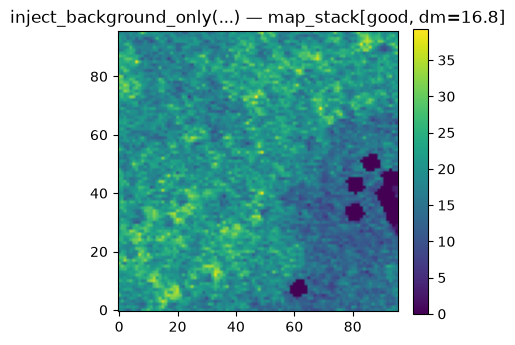

label_stack is all zero: True
params: {}


In [17]:
window_bg_only = sample_random_window(
    background.footprint, pix.nside, size_deg=size_deg, rng=np.random.default_rng(SEED + 1)
)
sample_bg_only = inject_background_only(background, window_bg_only, pix)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(sample_bg_only.map_stack[good_idx], origin="lower", cmap="viridis")
ax.set_title(f"inject_background_only(...) — map_stack[good, dm={closest_dm}]")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

print("label_stack is all zero:", bool(np.all(sample_bg_only.label_stack == 0.0)))
print("params:", sample_bg_only.params)

### 3.2 Final preparation: what the model actually sees

`inject_single_stream`'s `map_stack`/`label_stack` are the *physical*
quantities (counts), not what `models.unet.UNet` is actually fed --
training additionally normalizes `map_stack` per channel
(`datasets.transforms.RobustNormalizer`, fit on valid pixels only) and
leaves `label_stack` in raw counts (see `PLAN.md`/the docs' "Datasets and
models" page for why). This step reproduces that exact preparation on
`sample_minimal` and plots the true model input side by side with the raw
map, **explicitly masking invalid pixels** (`np.where(valid_mask, x,
np.nan)` + `cmap.set_bad`) rather than leaving them at their raw `0.0` fill
value blended in among the normalized data -- the trap documented in the
"Datasets and models" guide page: a raw `0.0` sitting inside an otherwise
mean-0/std-1 normalized channel can look like an unremarkable value rather
than the sentinel it is, unless you check `valid_mask` explicitly.


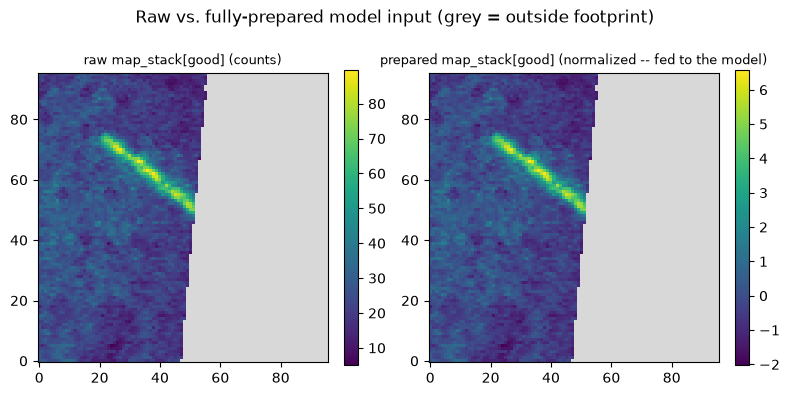

per-channel normalizer mean: [21.27818489 15.0073328  24.95351791 15.30359554]
per-channel normalizer std:  [5.87376213 4.16103983 9.84004784 4.37647104]
invalid pixels stay at their raw fill value after normalization: True


In [18]:
# A single sample's own valid pixels are enough to fit() here -- this
# notebook only wants to show what preparation *does*, not produce
# well-calibrated statistics (train_model.ipynb pools several samples
# instead, which is what a real training run should do).
normalizer = RobustNormalizer()
normalizer.fit(sample_minimal.map_stack, sample_minimal.valid_mask)

transform = StreamMapTransform(normalizer=normalizer, augment=False)
prepared = transform(
    {
        "map_stack": sample_minimal.map_stack,
        "label_stack": sample_minimal.label_stack,
        "valid_mask": sample_minimal.valid_mask,
        "params": sample_minimal.params,
        "metadata": sample_minimal.metadata,
    }
)

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad(color="0.85")


def _masked(img, valid_mask):
    return np.where(valid_mask, img, np.nan)


fig, axes = plt.subplots(1, 2, figsize=(8, 4))
im0 = axes[0].imshow(
    _masked(sample_minimal.map_stack[good_idx], sample_minimal.valid_mask),
    origin="lower",
    cmap=cmap,
)
axes[0].set_title("raw map_stack[good] (counts)", fontsize=9)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(
    _masked(prepared["map_stack"][good_idx], prepared["valid_mask"]), origin="lower", cmap=cmap
)
axes[1].set_title("prepared map_stack[good] (normalized -- fed to the model)", fontsize=9)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

fig.suptitle("Raw vs. fully-prepared model input (grey = outside footprint)")
plt.tight_layout()
plt.show()

print(f"per-channel normalizer mean: {normalizer.mean}")
print(f"per-channel normalizer std:  {normalizer.std}")
print(
    "invalid pixels stay at their raw fill value after normalization:",
    bool(
        np.all(
            prepared["map_stack"][:, ~prepared["valid_mask"]]
            == sample_minimal.map_stack[:, ~sample_minimal.valid_mask]
        )
    ),
)


## Summary

| Step-by-step (§2) | Minimal command (§3) |
|---|---|
| §2.4 `resolve_richness_to_nstars` + `StreamObsSource.realize` | `StreamInjector.inject_single_stream` step 1 |
| §2.5 `place_stream_in_footprint` | step 2 |
| §2.6 `ObsStreamInjector.inject` + `flag_col` filter + `apply_cuts`/`apply_magnitude_clipping` | steps 3-4 |
| §2.7 `sample_stream_window` | step 2 (window depends on placement, so it's sampled together with it) |
| §2.8 per (filter, distance): `select` + `make_raw_map` (raw count) + threshold at `count_threshold` (detection label) + `combine_full_maps` + `finalize_full` + `crop_window` | steps 5-7 |
| §2.9 `Sample(...)` | step 8 |

`Background.load_or_cache` (§2.3) is built once, outside the injector, and
handed in — that's what makes "every matched filter only ever touches the
background once, no matter how many streams get injected" true (verified in
`tests/test_injector.py::test_inject_single_stream_reuses_background_selection_across_injections`).

The "good" filter's label consistently beats the "decoy" filter's at the
stream's true distance
(`tests/test_injector.py::test_inject_single_stream_good_filter_label_beats_decoy_at_true_distance`
for the raw count,
`test_inject_single_stream_detection_policy_decoy_stays_below_threshold_at_true_distance`
for the thresholded detection label) — exactly the signal a stream-detection
network needs to learn from (PLAN.md §6.3, §6.12).